Model Building, Tuning & Evaluation


CELL 0 — Imports & paths

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform


from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    log_loss, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

# Optional (if installed)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

pd.set_option("display.max_columns", 200)
from pathlib import Path


ROOT = Path("..").resolve()                     # project root (one level up from notebooks/)
MODELS = ROOT / "models"
DATA_PROCESSED = ROOT / "data" / "processed"
DATA = DATA_PROCESSED / "processed_features"



CELL 1 — Load dataset & define splits

In [2]:
df = pd.read_csv(DATA / "match_level_dataset.csv", parse_dates=["date"])

# ensure season exists and string-typed
if "season" not in df.columns:
    # infer season (July cut-off)
    s = df["date"].dt.year - (df["date"].dt.month < 7).astype(int)
    df["season"] = s.astype(str)
else:
    df["season"] = df["season"].astype(str)

print(df.shape, sorted(df["season"].unique()))


(1372, 106) ['2020', '2022', '2023', '2024']


CELL 2 — Feature selection (drop leakage)

We exclude any same-match stats (e.g., home_xg, away_xg, home_poss, …). We only train on rolling & differential features.

In [3]:
#cell2
# # Label: 1 home win, 0 draw, -1 away win
y = df["result"].astype(int)

# columns that are safe: rolling (l3/l5/l10/exp*) + *_diff + historical sums
allowed_patterns = ("_l3","_l5","_l10","_exp","_sum_l","_diff")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [
    c for c in numeric_cols
    if c != "result" and c not in {"home_goals","away_goals"}
    and any(p in c for p in allowed_patterns)
]

X = df[feature_cols].copy()

# chronological splits
train_seasons = ["2021","2022","2023"]
val_seasons   = ["2024"]
test_seasons  = ["2025"]  # may be empty in your snapshot

X_train, y_train = X[df["season"].isin(train_seasons)], y[df["season"].isin(train_seasons)]
X_val,   y_val   = X[df["season"].isin(val_seasons)],   y[df["season"].isin(val_seasons)]
X_test,  y_test  = X[df["season"].isin(test_seasons)],  y[df["season"].isin(test_seasons)]

X_train.shape, X_val.shape, X_test.shape


((686, 82), (306, 82), (0, 82))

CELL 3 — Preprocessor

In [4]:
##cell3
# all features numeric -> impute + (optionally) scale
num_pipe_lr = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())  # LR benefits from scaling
])

num_pipe_tree = Pipeline([
    ("impute", SimpleImputer(strategy="median"))  # trees don't need scaling
])

preproc_lr = ColumnTransformer([("num", num_pipe_lr, feature_cols)], remainder="drop")
preproc_tree = ColumnTransformer([("num", num_pipe_tree, feature_cols)], remainder="drop")


CELL 4 — Baselines & grids

In [5]:
#cell4
# # ---- Cell 4: model definitions + search objects ---------------------------------
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV

# Time-aware CV (train folds earlier than validation folds)
tscv = TimeSeriesSplit(n_splits=5)

# encode {-1,0,1} → {0,1,2}
label_order  = sorted(y_train.unique())            # [-1, 0, 1]
label_to_idx = {label: idx for idx, label in enumerate(label_order)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_train_enc = y_train.map(label_to_idx).to_numpy()
y_val_enc   = y_val.map(label_to_idx).to_numpy()
y_test_enc  = y_test.map(label_to_idx).to_numpy() if len(y_test) else None

# sample weights (draws get ~80% more weight)
weight_map = {-1: 1.0, 0: 1.8, 1: 1.0}
sample_weights = y_train.map(weight_map).to_numpy()

# Logistic Regression — widened regularisation sweep
pipe_lr = Pipeline([
    ("prep", preproc_lr),
    ("clf", LogisticRegression(max_iter=1500, multi_class="multinomial"))
])
grid_lr = {
    "clf__C": [0.05, 0.1, 0.2, 0.5, 1.0, 2.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}
search_lr = GridSearchCV(
    pipe_lr, grid_lr,
    scoring="neg_log_loss",
    cv=tscv, n_jobs=-1, refit=True, verbose=0,
)

# Random Forest — richer space + random search
pipe_rf = Pipeline([
    ("prep", preproc_tree),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
])
rf_param_dist = {
    "clf__n_estimators": [400, 600, 800],
    "clf__max_depth": [6, 8, 10, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", 0.5, None],
    "clf__bootstrap": [True, False],
}
search_rf = RandomizedSearchCV(
    pipe_rf, rf_param_dist,
    n_iter=30, scoring="neg_log_loss",
    cv=tscv, n_jobs=-1, refit=True, random_state=42, verbose=0,
)

# XGBoost — broader random search (optional)
if HAS_XGB:
    pipe_xgb = Pipeline([
        ("prep", preproc_tree),
        ("clf", XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            tree_method="hist",
            n_jobs=-1,
            random_state=42,
        )),
    ])
    xgb_param_dist = {
        "clf__n_estimators": [400, 600, 800],
        "clf__max_depth": [3, 4, 5],
        "clf__learning_rate": [0.02, 0.03, 0.05],
        "clf__subsample": [0.7, 0.85, 1.0],
        "clf__colsample_bytree": [0.7, 0.85, 1.0],
        "clf__min_child_weight": [1, 3, 5],
        "clf__reg_lambda": [0.0, 0.5, 1.0],
        "clf__reg_alpha": [0.0, 0.5, 1.0],
    }
    search_xgb = RandomizedSearchCV(
        pipe_xgb, xgb_param_dist,
        n_iter=40, scoring="neg_log_loss",
        cv=tscv, n_jobs=-1, refit=True, random_state=42, verbose=0,
    )
else:
    search_xgb = None


CELL 5 — Time-aware CV on the training seasons

We keep validation (2024) fully held-out for model selection & calibration.

In [6]:
from sklearn.model_selection import TimeSeriesSplit

# Time-aware CV (train folds earlier than validation folds)
tscv = TimeSeriesSplit(n_splits=5)

# encode {-1,0,1} → {0,1,2}
label_order  = sorted(y_train.unique())            # [-1, 0, 1]
label_to_idx = {label: idx for idx, label in enumerate(label_order)}
idx_to_label = {idx: label for label, idx in label_to_idx.items()}

y_train_enc = y_train.map(label_to_idx).to_numpy()
y_val_enc   = y_val.map(label_to_idx).to_numpy()
y_test_enc  = y_test.map(label_to_idx).to_numpy() if len(y_test) else None
# ---- Cell X: run the time-aware searches and capture best estimators ----
fit_kwargs = {"clf__sample_weight": sample_weights}

# Logistic Regression
search_lr.fit(X_train, y_train_enc, **fit_kwargs)
print("LR best params :", search_lr.best_params_)
print("LR CV log_loss :", -search_lr.best_score_)
best_lr = search_lr.best_estimator_

# Random Forest
search_rf.fit(X_train, y_train_enc, **fit_kwargs)
print("RF best params :", search_rf.best_params_)
print("RF CV log_loss :", -search_rf.best_score_)
best_rf = search_rf.best_estimator_

# XGBoost (optional)
best_xgb = None
if search_xgb is not None:
    search_xgb.fit(X_train, y_train_enc, **fit_kwargs)
    print("XGB best params:", search_xgb.best_params_)
    print("XGB CV log_loss:", -search_xgb.best_score_)
    best_xgb = search_xgb.best_estimator_


e:\Football Analyst\Portfolio\Predictive-Models\match-outcome-ligue1\.ligueone\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LR best params : {'clf__C': 0.05, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
LR CV log_loss : 0.9663948916428481
RF best params : {'clf__n_estimators': 600, 'clf__min_samples_split': 5, 'clf__min_samples_leaf': 1, 'clf__max_features': 0.5, 'clf__max_depth': 6, 'clf__bootstrap': True}
RF CV log_loss : 0.9018395836095158
XGB best params: {'clf__subsample': 0.85, 'clf__reg_lambda': 0.0, 'clf__reg_alpha': 1.0, 'clf__n_estimators': 400, 'clf__min_child_weight': 5, 'clf__max_depth': 3, 'clf__learning_rate': 0.02, 'clf__colsample_bytree': 1.0}
XGB CV log_loss: 0.9367903629240143


CELL 6 — Pick champion on validation (2024)

In [7]:
# Collect tuned models (only include the ones you trained)
candidates = [
    ("LR", best_lr),
    ("RF", best_rf),
]
if HAS_XGB and best_xgb is not None:
    candidates.append(("XGB", best_xgb))

label_order = [-1, 0, 1]
label_to_idx = {lbl: idx for idx, lbl in enumerate(label_order)}
idx_to_label = {idx: lbl for lbl, idx in label_to_idx.items()}

y_val_enc = y_val.map(label_to_idx).to_numpy()

def decode_proba(proba):
    cols = [idx_to_label[i] for i in range(proba.shape[1])]
    proba_df = pd.DataFrame(proba, columns=cols)
    return proba_df[label_order].to_numpy()

scores = []
for name, mdl in candidates:
    proba_raw = mdl.predict_proba(X_val)
    proba = decode_proba(proba_raw)
    preds_enc = mdl.predict(X_val)
    preds = pd.Series(preds_enc).map(idx_to_label)

    scores.append({
        "model": name,
        "log_loss": log_loss(y_val, proba, labels=label_order),
        "accuracy": accuracy_score(y_val, preds),
        "macro_f1": f1_score(y_val, preds, average="macro"),
    })

pd.DataFrame(scores).sort_values("log_loss")


,model,log_loss,accuracy,macro_f1
1,RF,0.855871,0.637255,0.569599
0,LR,0.869812,0.624183,0.567565
2,XGB,0.880368,0.614379,0.528440


CELL 7 — Calibrate the chosen model (improves reliability)

In [8]:
from sklearn.calibration import CalibratedClassifierCV

champ_name = min(scores, key=lambda d: d["log_loss"])["model"]
champ = dict(candidates)[champ_name]

cal = CalibratedClassifierCV(estimator=champ, method="isotonic", cv="prefit")
cal.fit(X_val, y_val_enc)

val_proba_raw = cal.predict_proba(X_val)
val_pred_enc = cal.predict(X_val)

val_proba = decode_proba(val_proba_raw)
val_pred = pd.Series(val_pred_enc).map(idx_to_label)

print(f"Champion: {champ_name}")
print("VAL accuracy :", accuracy_score(y_val, val_pred))
print("VAL macro F1 :", f1_score(y_val, val_pred, average="macro"))
print("VAL log_loss :", log_loss(y_val, val_proba, labels=label_order))
print(classification_report(y_val, val_pred, digits=3))


e:\Football Analyst\Portfolio\Predictive-Models\match-outcome-ligue1\.ligueone\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Champion: RF
VAL accuracy : 0.6535947712418301
VAL macro F1 : 0.531789822063923
VAL log_loss : 0.77847230289909
              precision    recall  f1-score   support

          -1      0.588     0.762     0.664       101
           0      0.300     0.097     0.146        62
           1      0.755     0.818     0.785       143

    accuracy                          0.654       306
   macro avg      0.548     0.559     0.532       306
weighted avg      0.608     0.654     0.616       306



Cell 8 — (Recommended next step) Draw-threshold sweep

In [9]:
thresholds = np.linspace(0.38, 0.65, 20)

best = None
for t in thresholds:
    top_prob = val_proba.max(axis=1)
    top_idx = val_proba.argmax(axis=1)
    preds = np.array([label_order[i] for i in top_idx])
    preds[top_prob < t] = 0  # force draw when confidence low

    macro = f1_score(y_val, preds, average="macro")
    if best is None or macro > best["macro"]:
        best = {"threshold": t, "macro": macro, "preds": preds}

print("Best threshold:", best["threshold"], "macro F1:", best["macro"])
print("VAL accuracy:", accuracy_score(y_val, best["preds"]))
print(classification_report(y_val, best["preds"], digits=3))


Best threshold: 0.4368421052631579 macro F1: 0.5831061348812308
VAL accuracy: 0.6666666666666666
              precision    recall  f1-score   support

          -1      0.620     0.743     0.676       101
           0      0.400     0.226     0.289        62
           1      0.767     0.804     0.785       143

    accuracy                          0.667       306
   macro avg      0.596     0.591     0.583       306
weighted avg      0.644     0.667     0.648       306



 Confusion matrix (validation)

,Pred -1,Pred 0,Pred 1
True -1,75,10,16
True 0,29,14,19
True 1,17,11,115


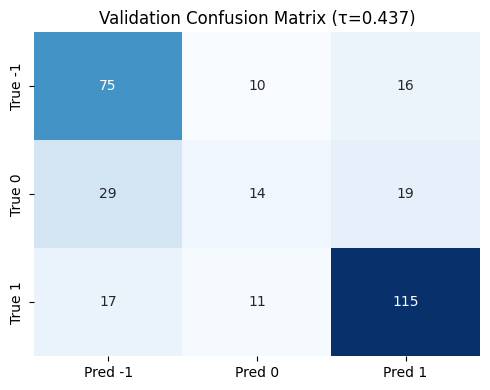

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion(y_true, y_pred, labels=(-1, 0, 1), title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"True {lbl}" for lbl in labels],
                               columns=[f"Pred {lbl}" for lbl in labels])

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    return cm_df

# After you compute `best["preds"]` (the draw-threshold outputs):
cm_val = plot_confusion(y_val, best["preds"], labels=label_order,
                        title=f"Validation Confusion Matrix (τ={best['threshold']:.3f})")
cm_val


Test set Evaluation 

In [11]:
if len(X_test) > 0:
    test_proba = cal.predict_proba(X_test)
    test_pred  = cal.predict(X_test)
    print("TEST accuracy:", accuracy_score(y_test, test_pred))
    print("TEST macro F1:", f1_score(y_test, test_pred, average="macro"))
    print("TEST log_loss:", log_loss(y_test, test_proba))
    print(classification_report(y_test, test_pred, digits=3))
else:
    print("No TEST season available in the snapshot (expected).")


No TEST season available in the snapshot (expected).


Exports for PowerBI

In [12]:
# === Export predictions for Power BI ===
from pathlib import Path

# 1) Choose the slice you want to export (here: validation season 2024)
export_mask = df["season"].isin(["2024"])
export_df = df.loc[export_mask, ["match_id", "date", "season", "home", "away", "result"]].copy()

X_export = X.loc[export_mask]

# 2) Get calibrated probabilities
proba_raw = cal.predict_proba(X_export)
proba = decode_proba(proba_raw)          # columns ordered as [-1, 0, 1]
top_prob = proba.max(axis=1)
top_idx = proba.argmax(axis=1)

# 3) Apply the draw threshold that came out of the sweep
best_threshold = 0.436842052631579       # replace with the threshold you selected
pred_encoded = np.array([label_order[i] for i in top_idx])
pred_encoded[top_prob < best_threshold] = 0  # override to draw when confidence is low

# 4) Assemble columns for Power BI
label_names = {-1: "Away Win", 0: "Draw", 1: "Home Win"}

export_df["prob_away_win"] = proba[:, 0]
export_df["prob_draw"]     = proba[:, 1]
export_df["prob_home_win"] = proba[:, 2]
export_df["pred_label"]    = pred_encoded
export_df["pred_label_text"] = export_df["pred_label"].map(label_names)
export_df["draw_override"] = (top_prob < best_threshold)

# Optional: keep track of actual vs predicted outcome text
export_df["actual_label_text"] = export_df["result"].map(label_names)
ROOT = Path("..").resolve()                     # project root (one level up from notebooks/)
MODELS = ROOT / "models"
DATA_PROCESSED = ROOT / "data" / "processed"
DATA = DATA_PROCESSED / "processed_features"

# 5) Persist to CSV for Power BI
out_dir = ROOT / "data" / "processed" / "processed_features"
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "val_predictions_powerbi.csv"
export_df.to_csv(out_path, index=False)

print(f"Saved Power BI export -> {out_path}")
export_df.head()


Saved Power BI export -> E:\Football Analyst\Portfolio\Predictive-Models\match-outcome-ligue1\data\processed\processed_features\val_predictions_powerbi.csv


,match_id,date,season,home,away,result,prob_away_win,prob_draw,prob_home_win,pred_label,pred_label_text,draw_override,actual_label_text
57,20240818_Angers_Lens,2024-08-18 15:00:00,2024,Angers,Lens,-1,0.657718,0.199664,0.142617,-1,Away Win,False,Away Win
58,20240901_Angers_Nice,2024-09-01 15:00:00,2024,Angers,Nice,-1,0.567130,0.309896,0.122975,-1,Away Win,False,Away Win
59,20240922_Angers_Nantes,2024-09-22 15:00:00,2024,Angers,Nantes,0,0.632462,0.230397,0.137141,-1,Away Win,False,Draw
60,20240929_Angers_Reims,2024-09-29 15:00:00,2024,Angers,Reims,-1,0.641702,0.219153,0.139145,-1,Away Win,False,Away Win
61,20241026_Angers_Saint-Etienne,2024-10-26 15:00:00,2024,Angers,Saint-Etienne,1,0.029787,0.121277,0.848936,1,Home Win,False,Home Win


Reliability curves (one-vs-rest for each outcome)

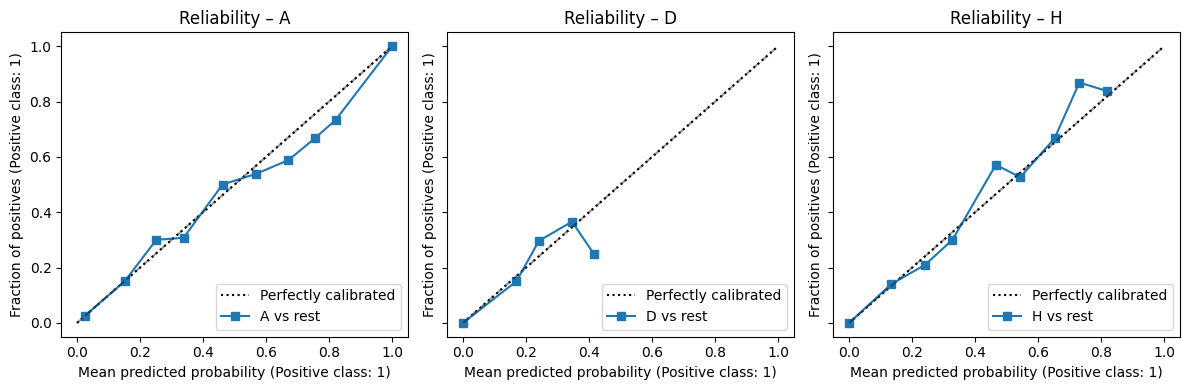

In [13]:
from sklearn.calibration import CalibrationDisplay

# assumes `val_proba` (decoded to [-1,0,1]) and `label_order`, `label_symbols` already exist
label_symbols = {-1: "A", 0: "D", 1: "H"}

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for idx, label in enumerate(label_order):
    CalibrationDisplay.from_predictions(
        y_true=(y_val == label).astype(int),
        y_prob=val_proba[:, idx],
        n_bins=10,
        name=f"{label_symbols[label]} vs rest",
        ax=axes[idx]
    )
    axes[idx].plot([0, 1], [0, 1], "k--", alpha=0.4)
    axes[idx].set_title(f"Reliability – {label_symbols[label]}")

plt.tight_layout()


Per-season metrics (using the calibrated model + draw threshold)

In [14]:
from sklearn.metrics import accuracy_score, f1_score, log_loss
from collections import defaultdict

best_threshold = 0.436842052631579  # replace with your chosen threshold

def apply_threshold(proba, threshold):
    top_prob = proba.max(axis=1)
    top_idx = proba.argmax(axis=1)
    preds = np.array([label_order[i] for i in top_idx])
    preds[top_prob < threshold] = 0  # force draw when confidence low
    return preds

season_metrics = []

for season, mask in df.groupby("season"):
    X_season = X.loc[mask.index]
    y_season = y.loc[mask.index]
    y_season_enc = y_season.map(label_to_idx).to_numpy()

    proba_raw = cal.predict_proba(X_season)
    proba = decode_proba(proba_raw)
    preds_threshold = apply_threshold(proba, best_threshold)

    metrics = {
        "season": season,
        "log_loss": log_loss(y_season, proba, labels=label_order),
        "accuracy": accuracy_score(y_season, preds_threshold),
        "macro_f1": f1_score(y_season, preds_threshold, average="macro"),
        "draw_recall": f1_score((y_season == 0).astype(int),
                                (preds_threshold == 0).astype(int),
                                average="binary"),
    }
    season_metrics.append(metrics)

pd.DataFrame(season_metrics).sort_values("season")


,season,log_loss,accuracy,macro_f1,draw_recall
0,2020,1.144850,0.600000,0.555518,0.314465
1,2022,0.500376,0.871053,0.859363,0.785276
2,2023,0.527313,0.846405,0.831038,0.727273
3,2024,0.778472,0.666667,0.583106,0.288660


In [15]:
model_path = MODELS / "champion_calibrated.joblib"
meta_path  = MODELS / "model_card.json"

artifact = {
    "model": cal,                                   # CalibratedClassifierCV (fit)
    "tau_draw": best["threshold"],                  # draw override threshold
    "label_order": label_order[:],                  # original labels e.g. [-1, 0, 1]
    "encoded_classes": cal.classes_.tolist(),       # model.classes_ (often [0,1,2])
    "label_symbols": {-1: "A", 0: "D", 1: "H"},
    "feature_cols": feature_cols,
}
joblib.dump(artifact, model_path)

model_card = {
    "model_name": f"{champ_name} + isotonic calibration",
    "timestamp": pd.Timestamp.utcnow().isoformat(),
    "train_seasons": train_seasons,                 # update if refitting on train+val
    "val_seasons": val_seasons,
    "test_seasons": test_seasons,
    "features_used": feature_cols,
    "tau_draw": best["threshold"],
    "scoring_metric": "log_loss (time-series CV)",
    "calibration": "Isotonic; cv='prefit' on validation set",
    "class_weighting": "sample weights {-1:1.0, 0:1.8, 1:1.0}",
    "notes": [
        "Only rolling/differential features; no same-match stats.",
        "Calibrated probabilities; draw prediction uses low-confidence override.",
        "Update train/val season lists if refit on combined data before deployment.",
    ],
}
with open(meta_path, "w") as f:
    json.dump(model_card, f, indent=2)

print("Saved model:", model_path)
print("Saved model card:", meta_path)


Saved model: E:\Football Analyst\Portfolio\Predictive-Models\match-outcome-ligue1\models\champion_calibrated.joblib
Saved model card: E:\Football Analyst\Portfolio\Predictive-Models\match-outcome-ligue1\models\model_card.json


In [16]:
import pandas as pd

fixtures = pd.DataFrame({
    "date": ["2025-08-10", "2025-08-11"],
    "home": ["PSG", "Marseille"],
    "away": ["Lyon", "Monaco"],
})
fixtures.to_csv("fixtures_sample.csv", index=False)


Feature importances for Power BI

In [17]:

# === Feature importances for Power BI ===
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    cal,
    X_val,
    y_val_enc,
    n_repeats=20,
    random_state=42,
    scoring="neg_log_loss",
)

importance_df = (
    pd.DataFrame(
        {
            "feature": feature_cols,
            "importance_mean": perm_result.importances_mean,
            "importance_std": perm_result.importances_std,
        }
    )
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

out_path = ROOT / "reports" / "dashboard" / "feature_importance.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)

importance_df.to_csv(out_path, index=False)
print(f"Saved feature importances -> {out_path}")

importance_df.head(10)


Saved feature importances -> E:\Football Analyst\Portfolio\Predictive-Models\match-outcome-ligue1\reports\dashboard\feature_importance.csv


,feature,importance_mean,importance_std
0,home_npxg_l5_diff,0.342701,0.060400
1,home_xg_diff,0.339494,0.088853
2,home_poss_exp80,0.244706,0.077503
3,away_xg_l3,0.242471,0.120158
4,home_yellow_cards_sum_l10,0.215307,0.033037
5,home_poss_exp80_diff,0.154177,0.090785
6,home_npxg_diff,0.153604,0.089634
7,away_npxg_exp80,0.151928,0.060172
8,home_xg_l5_diff,0.148390,0.069552
9,home_poss_diff,0.117976,0.058026
